In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import norm

from pygam import LinearGAM, s, te
from arch import arch_model
from sklearn.metrics import (
    recall_score, precision_score, accuracy_score, f1_score, confusion_matrix
)

# -------------------------
# Configuration and Paths
# -------------------------
# 設定專案的根目錄與輸出圖片的資料夾路徑
PROJECT_DIRECTORY = Path.cwd().parents[0]  
PLOT_OUTPUT_DIRECTORY = PROJECT_DIRECTORY / "Assets" / "Outputs" / "Model" / "image"     

# 確保輸出資料夾存在，若不存在則自動建立
PLOT_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

In [2]:
# -------------------------
# Math & Threshold Helpers
# -------------------------
def calculate_garch_sigma_manually(
    residuals_array, omega_constant, alpha_coefficient, beta_coefficient, 
    last_residual_from_training, last_variance_from_training
):
    """
    手動計算 GARCH(1,1) 模型的條件標準差 (Conditional Standard Deviation)。
    
    Args:
        residuals_array (np.ndarray): 測試集的殘差陣列。
        omega_constant (float): GARCH 模型的常數項 (omega)。
        alpha_coefficient (float): GARCH 模型的誤差項係數 (alpha)。
        beta_coefficient (float): GARCH 模型的歷史變異數係數 (beta)。
        last_residual_from_training (float): 訓練集/校正集最後一筆殘差。
        last_variance_from_training (float): 訓練集/校正集最後一筆變異數。

    Returns:
        np.ndarray: 每個時間點的條件標準差 (Sigma) 陣列。
    """
    total_time_steps = len(residuals_array)
    conditional_variances = np.zeros(total_time_steps)
    
    current_residual = float(last_residual_from_training)
    current_variance = float(last_variance_from_training)

    # 透過 GARCH(1,1) 公式迭代計算每一個時間點的變異數
    for time_index in range(total_time_steps):
        next_variance = omega_constant + alpha_coefficient * (current_residual**2) + beta_coefficient * current_variance
        conditional_variances[time_index] = next_variance
        
        # 更新狀態以供下一個時間點使用
        current_variance = next_variance
        current_residual = residuals_array[time_index]

    # 取平方根將變異數轉換為標準差，並加上 1e-12 避免數值計算出現 0 的情況
    return np.sqrt(np.maximum(conditional_variances, 1e-12))


def calculate_naive_max3_recall(time_series_data, pm25_threshold=15, evaluation_year=2024):
    """
    (保留供未來實驗用) 計算一個簡單基準模型 (Naive Baseline) 的 Recall。
    該基準模型的邏輯是：如果過去 3 小時內有任何一小時超標，就預測未來會超標。
    
    Args:
        time_series_data (pd.Series): 單一區域的 PM2.5 時間序列資料。
        pm25_threshold (float): PM2.5 實體超標的數值閾值。
        evaluation_year (int): 要進行評估的年份。

    Returns:
        float: 基準模型的 Recall 數值。
    """
    time_series_float = time_series_data.astype(float)
    lag_dataframe = pd.DataFrame(index=time_series_float.index)
    
    # 建立歷史滯後特徵 (Lag 0, 1, 2) 與未來目標值 (t+3)
    lag_dataframe["lag_0"] = time_series_float
    lag_dataframe["lag_1"] = time_series_float.shift(1)
    lag_dataframe["lag_2"] = time_series_float.shift(2)
    lag_dataframe["target_t_plus_3"] = time_series_float.shift(-3)
    
    # 移除空值並篩選特定年份
    lag_dataframe = lag_dataframe.dropna()
    lag_dataframe = lag_dataframe[lag_dataframe.index.year == evaluation_year]
    if len(lag_dataframe) == 0:
        return np.nan

    # 判斷實際是否超標與預測是否超標
    actual_exceedance = (lag_dataframe["target_t_plus_3"] > pm25_threshold).astype(int).values
    predicted_exceedance = (
        (lag_dataframe["lag_0"] > pm25_threshold) | 
        (lag_dataframe["lag_1"] > pm25_threshold) | 
        (lag_dataframe["lag_2"] > pm25_threshold)
    ).astype(int).values
    
    return float(recall_score(actual_exceedance, predicted_exceedance, zero_division=0))


def select_probability_threshold(
    predicted_probabilities, actual_binary_labels, selection_mode="fixed", 
    fixed_probability_threshold=0.35, target_recall_score=None
):
    """
    決定觸發警報的機率閾值 (Probability Threshold)。
    
    Args:
        predicted_probabilities (np.ndarray): 模型預測超標的機率陣列。
        actual_binary_labels (np.ndarray): 實際是否超標的二元標籤 (0 或 1)。
        selection_mode (str): 閾值選擇模式 ("fixed" 或 "target_recall_max3")。
        fixed_probability_threshold (float): 若模式為 fixed，則直接回傳此固定的閾值。
        target_recall_score (float): 若模式為 target_recall_max3，所要達到的目標 Recall 最小值。

    Returns:
        tuple: (選定的機率閾值, 包含不同閾值測試結果的 DataFrame)。
    """
    if selection_mode == "fixed":
        return float(fixed_probability_threshold), None

    # 保留未來動態搜尋最佳閾值的邏輯：測試 0.01 到 0.99 之間的 99 個可能性
    threshold_grid = np.linspace(0.01, 0.99, 99)
    evaluation_metrics_rows = []
    
    for candidate_threshold in threshold_grid:
        binary_predictions = (predicted_probabilities >= candidate_threshold).astype(int)
        evaluation_metrics_rows.append((
            candidate_threshold, 
            recall_score(actual_binary_labels, binary_predictions, zero_division=0),
            precision_score(actual_binary_labels, binary_predictions, zero_division=0),
            f1_score(actual_binary_labels, binary_predictions, zero_division=0)
        ))
        
    metrics_dataframe = pd.DataFrame(
        evaluation_metrics_rows, 
        columns=["probability_threshold", "recall", "precision", "f1_score"]
    )

    if selection_mode == "target_recall_max3":
        if target_recall_score is not None and np.isfinite(target_recall_score):
            # 找出符合目標 Recall 條件的候選閾值
            feasible_thresholds = metrics_dataframe[metrics_dataframe["recall"] >= target_recall_score]
            if len(feasible_thresholds) > 0:
                # 在符合條件的閾值中，挑選 Precision 最高者
                best_threshold_row = feasible_thresholds.sort_values(
                    ["precision", "f1_score", "probability_threshold"], 
                    ascending=[False, False, False]
                ).iloc[0]
                return float(best_threshold_row["probability_threshold"]), metrics_dataframe
                
        # 退回使用 F1 Score 最高的選項
        best_threshold_row = metrics_dataframe.sort_values(
            ["f1_score", "precision"], ascending=[False, False]
        ).iloc[0]
        return float(best_threshold_row["probability_threshold"]), metrics_dataframe

    raise ValueError("selection_mode must be 'fixed' or 'target_recall_max3'")

In [3]:
# -------------------------
# Feature Engineering
# -------------------------
def append_lagged_features(input_dataframe, target_column_name='target_variable', lag_hours=(3, 24, 48)):
    """
    加入歷史滯後特徵 (Lagged Features)。
    
    Args:
        input_dataframe (pd.DataFrame): 輸入的原始資料表。
        target_column_name (str): 要產生滯後特徵的目標欄位名稱。
        lag_hours (tuple): 要產生哪些小時數的滯後特徵。

    Returns:
        pd.DataFrame: 附帶滯後特徵的資料表。
    """
    processed_dataframe = input_dataframe.copy()
    for lag_value in lag_hours:
        lag_column_name = f'lag_{lag_value}h'
        processed_dataframe[lag_column_name] = processed_dataframe[target_column_name].shift(lag_value)
    return processed_dataframe


def append_temporal_features(input_dataframe):
    """
    加入時間週期特徵 (Temporal Features)，例如小時、星期、月份。
    
    Args:
        input_dataframe (pd.DataFrame): 必須具備 DatetimeIndex 的資料表。

    Returns:
        pd.DataFrame: 附帶時間週期特徵的資料表。
    """
    processed_dataframe = input_dataframe.copy()
    processed_dataframe['hour_of_day'] = processed_dataframe.index.hour
    processed_dataframe['day_of_week'] = processed_dataframe.index.dayofweek
    processed_dataframe['month_of_year'] = processed_dataframe.index.month
    return processed_dataframe


def generate_regional_feature_pipeline(target_time_series):
    """
    整合單一區域的特徵工程管線 (Pipeline)。
    
    Args:
        target_time_series (pd.Series): 單一區域的時間序列資料。

    Returns:
        pd.DataFrame: 清理完成並具備所有所需特徵的資料表。
    """
    return (
        pd.DataFrame({'target_variable': target_time_series})
        .pipe(append_lagged_features, target_column_name='target_variable', lag_hours=(3, 24, 48))
        .pipe(append_temporal_features)
        .dropna() # 移除因 Shift 產生空值的資料列
    )

In [4]:
# -------------------------
# Modeling & Inference Modules
# -------------------------
def train_regional_gam_models(input_dataframe, training_end_year=2023):
    """
    針對每個區域訓練廣義加成模型 (GAM)。
    
    Args:
        input_dataframe (pd.DataFrame): 包含各區域 PM2.5 的寬格式(Wide format)資料表。
        training_end_year (int): 訓練資料的截止年份 (不包含該年)。

    Returns:
        dict: 儲存各區域已訓練完畢的 GAM 模型字典。
    """
    sorted_dataframe = input_dataframe.copy().sort_index()
    trained_models_dictionary = {}
    
    # 定義模型所需要吃進去的特徵欄位
    feature_columns = ['lag_3h', 'lag_24h', 'lag_48h', 'hour_of_day', 'day_of_week', 'month_of_year']

    for region_name in sorted_dataframe.columns:
        print(f">>> Training GAM for Region: {region_name}")
        
        # 準備該區域的特徵
        regional_features_dataframe = generate_regional_feature_pipeline(sorted_dataframe[region_name])
        training_dataset = regional_features_dataframe[regional_features_dataframe.index.year < training_end_year]
        
        if len(training_dataset) < 200:
            print(f"   [Skip] Too few training samples: {len(training_dataset)}")
            continue

        # 初始化並訓練 GAM 模型
        gam_model = LinearGAM(
            s(0) + s(1) + s(2) +
            te(3, 4, n_splines=[12, 7]) +
            te(3, 5, basis=['cp', 'ps'], n_splines=[12, 6]),
            lam=0.2454
        ).fit(training_dataset[feature_columns], training_dataset['target_variable'])

        trained_models_dictionary[region_name] = gam_model
        explained_deviance = gam_model.statistics_['pseudo_r2']['explained_deviance']
        print(f"   ✅ Fitted successfully. Pseudo R2: {explained_deviance:.4f}")
        
    return trained_models_dictionary


def fit_calibration_garch_model(calibration_residuals):
    """
    利用校正集(Calibration Set)的殘差來擬合 GARCH 模型，以獲取變異數參數。
    
    Args:
        calibration_residuals (np.ndarray): GAM 模型在校正集上的預測殘差。

    Returns:
        dict: 包含 GARCH 參數 (omega, alpha, beta) 與最後一筆狀態的字典。
    """
    arch_model_instance = arch_model(
        calibration_residuals, p=1, q=1, vol="Garch", dist="normal", rescale=False
    )
    fitted_garch_results = arch_model_instance.fit(disp="off")
    garch_parameters = fitted_garch_results.params
    
    return {
        "omega_constant": float(garch_parameters["omega"]),
        "alpha_coefficient": float(garch_parameters["alpha[1]"]),
        "beta_coefficient": float(garch_parameters["beta[1]"]),
        "last_residual_value": float(np.asarray(fitted_garch_results.resid)[-1]),
        "last_variance_value": float(np.asarray(fitted_garch_results.conditional_volatility)[-1] ** 2)
    }


def calculate_classification_metrics_dictionary(actual_labels, predicted_labels, region_name, probability_threshold):
    """
    計算並回傳標準的分類器評估指標。
    
    Args:
        actual_labels (np.ndarray): 真實的二元標籤。
        predicted_labels (np.ndarray): 預測的二元標籤。
        region_name (str): 區域名稱。
        probability_threshold (float): 使用的機率閾值。

    Returns:
        dict: 包含 Precision, Recall, Accuracy, F1 Score 的字典。
    """
    return {
        "Region_Name": region_name,
        "Applied_Probability_Threshold": probability_threshold,
        "Recall_Score": float(recall_score(actual_labels, predicted_labels, zero_division=0)),
        "Precision_Score": float(precision_score(actual_labels, predicted_labels, zero_division=0)),
        "Accuracy_Score": float(accuracy_score(actual_labels, predicted_labels)),
        "F1_Score": float(f1_score(actual_labels, predicted_labels, zero_division=0))
    }


def generate_classification_warning_pipeline(
    input_dataframe, trained_gam_models_dictionary, pm25_physical_threshold=15, 
    risk_probability_threshold=0.35, confidence_interval_level=0.90, 
    garch_calibration_year=2024, testing_year=2025, threshold_selection_mode="fixed"
):
    """
    結合 GAM 模型與 GARCH 殘差變異推論，產出最終的分類警報 (Classification Warning)。
    
    Args:
        input_dataframe (pd.DataFrame): 原始的時間序列資料表。
        trained_gam_models_dictionary (dict): 已經訓練好的 GAM 模型字典。
        pm25_physical_threshold (float): 定義 PM2.5 數值超過多少算作「超標實體事件」。
        risk_probability_threshold (float): 模型認為超標機率超過多少時，系統要「觸發警報」。
        confidence_interval_level (float): 用於繪圖的信心區間等級 (預設 90%)。
        garch_calibration_year (int): 用來擬合 GARCH 與找尋最佳閾值的校正年份。
        testing_year (int): 最終推論與評估成效的測試年份。
        threshold_selection_mode (str): 閾值決定模式 ("fixed" 或 "target_recall_max3")。

    Returns:
        tuple: (分類成效報表 DataFrame, 各區域詳細推論結果字典, 動態閾值測試記錄表)
    """
    sorted_dataframe = input_dataframe.copy().sort_index()
    z_score_for_ci = norm.ppf(0.5 + confidence_interval_level / 2)
    feature_columns = ["lag_3h", "lag_24h", "lag_48h", "hour_of_day", "day_of_week", "month_of_year"]
    
    classification_summary_list = []
    detailed_inference_dictionary = {}
    dynamic_threshold_records = {}

    for region_name, gam_model in trained_gam_models_dictionary.items():
        regional_features_dataframe = generate_regional_feature_pipeline(sorted_dataframe[region_name])
        
        # 篩選校正年份與測試年份的遮罩
        is_calibration_year = (regional_features_dataframe.index.year == garch_calibration_year)
        is_testing_year = (regional_features_dataframe.index.year == testing_year)
        
        if is_calibration_year.sum() == 0 or is_testing_year.sum() == 0:
            continue

        # ==========================================
        # 1. Calibration Phase (校正階段)
        # ==========================================
        calibration_dataset = regional_features_dataframe.loc[is_calibration_year]
        predicted_mean_calibration = gam_model.predict(calibration_dataset[feature_columns])
        actual_values_calibration = calibration_dataset["target_variable"].values
        residuals_calibration = actual_values_calibration - predicted_mean_calibration
        
        # 擬合 GARCH 取得變異數狀態
        garch_parameters = fit_calibration_garch_model(residuals_calibration)
        
        predicted_std_dev_calibration = calculate_garch_sigma_manually(
            residuals_calibration, 
            garch_parameters["omega_constant"], garch_parameters["alpha_coefficient"], garch_parameters["beta_coefficient"], 
            garch_parameters["last_residual_value"], garch_parameters["last_variance_value"]
        )
        
        # 計算校正集上「超過 PM2.5 實體閾值」的機率
        exceedance_probabilities_calibration = 1 - norm.cdf(
            (pm25_physical_threshold - predicted_mean_calibration) / (predicted_std_dev_calibration + 1e-12)
        )
        
        # 決定警報觸發的機率閾值 (Thresholding)
        target_recall_for_dynamic = calculate_naive_max3_recall(sorted_dataframe[region_name], pm25_physical_threshold, garch_calibration_year) if threshold_selection_mode == "target_recall_max3" else None
        
        actual_binary_labels_calibration = (actual_values_calibration > pm25_physical_threshold).astype(int)
        applied_probability_threshold, threshold_metrics_dataframe = select_probability_threshold(
            exceedance_probabilities_calibration, 
            actual_binary_labels_calibration, 
            selection_mode=threshold_selection_mode, 
            fixed_probability_threshold=risk_probability_threshold, 
            target_recall_score=target_recall_for_dynamic
        )
        dynamic_threshold_records[region_name] = threshold_metrics_dataframe

        # ==========================================
        # 2. Testing & Inference Phase (推論階段)
        # ==========================================
        testing_dataset = regional_features_dataframe.loc[is_testing_year]
        predicted_mean_testing = gam_model.predict(testing_dataset[feature_columns])
        actual_values_testing = testing_dataset["target_variable"].values
        residuals_testing = actual_values_testing - predicted_mean_testing
        
        predicted_std_dev_testing = calculate_garch_sigma_manually(
            residuals_testing, 
            garch_parameters["omega_constant"], garch_parameters["alpha_coefficient"], garch_parameters["beta_coefficient"], 
            garch_parameters["last_residual_value"], garch_parameters["last_variance_value"]
        )
        
        # 計算測試集上「超過 PM2.5 實體閾值」的機率
        exceedance_probabilities_testing = 1 - norm.cdf(
            (pm25_physical_threshold - predicted_mean_testing) / (predicted_std_dev_testing + 1e-12)
        )
        
        # 定義 Ground Truth (真實超標事件) 與 Prediction (是否觸發警報)
        actual_binary_labels_testing = (actual_values_testing > pm25_physical_threshold).astype(int)
        predicted_warning_triggers = (exceedance_probabilities_testing >= applied_probability_threshold).astype(int)
        
        # 紀錄整體評估報表
        classification_summary_list.append(
            calculate_classification_metrics_dictionary(
                actual_binary_labels_testing, predicted_warning_triggers, 
                region_name, applied_probability_threshold
            )
        )

        # 紀錄繪圖需要的詳細 DataFrame
        region_detail_dataframe = pd.DataFrame(index=testing_dataset.index)
        region_detail_dataframe["actual_pm25_value"] = actual_values_testing
        region_detail_dataframe["predicted_mean"] = predicted_mean_testing
        region_detail_dataframe["predicted_std_dev"] = predicted_std_dev_testing
        
        # 計算繪圖用的 90% 信心區間上下界
        region_detail_dataframe["confidence_interval_lower"] = predicted_mean_testing - z_score_for_ci * predicted_std_dev_testing
        region_detail_dataframe["confidence_interval_upper"] = predicted_mean_testing + z_score_for_ci * predicted_std_dev_testing
        
        region_detail_dataframe["exceedance_probability"] = exceedance_probabilities_testing
        region_detail_dataframe["is_actual_exceedance"] = actual_binary_labels_testing
        region_detail_dataframe["is_warning_triggered"] = predicted_warning_triggers
        
        # 計算 Confusion Matrix 元素用於繪圖著色
        region_detail_dataframe["is_true_positive"] = region_detail_dataframe["is_actual_exceedance"].eq(1) & region_detail_dataframe["is_warning_triggered"].eq(1)
        region_detail_dataframe["is_false_positive"] = region_detail_dataframe["is_actual_exceedance"].eq(0) & region_detail_dataframe["is_warning_triggered"].eq(1)
        region_detail_dataframe["is_false_negative"] = region_detail_dataframe["is_actual_exceedance"].eq(1) & region_detail_dataframe["is_warning_triggered"].eq(0)
        
        detailed_inference_dictionary[region_name] = region_detail_dataframe

    # 將 List 轉換為 DataFrame 並整理輸出
    summary_report_dataframe = pd.DataFrame(classification_summary_list).set_index("Region_Name").sort_values("Recall_Score", ascending=False)
    
    return summary_report_dataframe, detailed_inference_dictionary, dynamic_threshold_records

In [5]:
# -------------------------
# Plotting Module
# -------------------------
def plot_classification_warning_diagnostics(
    region_name, detailed_inference_dictionary, summary_report_dataframe, 
    pm25_physical_threshold=15, risk_probability_threshold=0.35, plot_days_limit=60
):
    """
    繪製警報系統的成效診斷圖表，包含兩張時間序列圖與一張混淆矩陣圖。
    
    Args:
        region_name (str): 要繪圖的區域名稱。
        detailed_inference_dictionary (dict): 儲存各區域預測詳細資訊的字典。
        summary_report_dataframe (pd.DataFrame): 儲存各區域整體成效指標的資料表。
        pm25_physical_threshold (float): PM2.5 超標的實體閾值。
        risk_probability_threshold (float): 觸發警報的機率閾值。
        plot_days_limit (int): 時間序列圖要展示的最初天數長度 (避免圖表過度壅擠)。
    """
    region_plot_dataframe = detailed_inference_dictionary[region_name].copy().sort_index()
    
    # 擷取指定天數區間的資料來繪圖
    if plot_days_limit is not None:
        end_time_for_plot = region_plot_dataframe.index.min() + pd.Timedelta(days=plot_days_limit)
        region_plot_dataframe = region_plot_dataframe.loc[region_plot_dataframe.index < end_time_for_plot]

    # 建立 2 個子圖的時間序列畫布
    figure, plot_axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, constrained_layout=True)
    performance_metrics_row = summary_report_dataframe.loc[region_name]

    # ----------------------------------------------------
    # Subplot 1: 實際數值預測與信心區間 (Fit + Confidence Interval)
    # ----------------------------------------------------
    plot_axes[0].plot(region_plot_dataframe.index, region_plot_dataframe['actual_pm25_value'], color='black', lw=1.2, label='Actual PM2.5')
    plot_axes[0].plot(region_plot_dataframe.index, region_plot_dataframe['predicted_mean'], color='tab:blue', lw=1.2, label='Predicted Mean')
    plot_axes[0].fill_between(
        region_plot_dataframe.index, 
        region_plot_dataframe['confidence_interval_lower'], 
        region_plot_dataframe['confidence_interval_upper'], 
        color='tab:blue', alpha=0.2, label='90% Confidence Interval'
    )
    plot_axes[0].axhline(pm25_physical_threshold, color='red', ls='--', lw=1.2, label=f'PM2.5 Threshold={pm25_physical_threshold}')
    
    # 標示出真實發生超標的點
    actual_event_indices = region_plot_dataframe.index[region_plot_dataframe['is_actual_exceedance'] == 1]
    plot_axes[0].scatter(
        actual_event_indices, region_plot_dataframe.loc[actual_event_indices, 'actual_pm25_value'], 
        s=18, color='red', alpha=0.8, label='Actual Exceedance Event'
    )
    
    # 設定標題與圖例
    plot_title = (
        f"{region_name} Warning Performance | "
        f"Precision={performance_metrics_row['Precision_Score']:.3f} "
        f"Recall={performance_metrics_row['Recall_Score']:.3f} "
        f"F1 Score={performance_metrics_row['F1_Score']:.3f}"
    )
    plot_axes[0].set_title(plot_title)
    plot_axes[0].legend(loc='upper right')
    plot_axes[0].grid(alpha=0.25)

    # ----------------------------------------------------
    # Subplot 2: 警報機率與觸發判定 (Probability & Warning Triggers)
    # ----------------------------------------------------
    plot_axes[1].plot(region_plot_dataframe.index, region_plot_dataframe['exceedance_probability'], color='purple', lw=1.1, label='Probability(PM2.5 > Threshold)')
    plot_axes[1].axhline(risk_probability_threshold, color='orange', ls='--', lw=1.2, label=f'Warning Trigger Threshold={risk_probability_threshold}')
    
    # 使用散佈圖標示出警報狀態 (TP / FP / FN)
    tp_indices = region_plot_dataframe.index[region_plot_dataframe['is_true_positive']]
    fp_indices = region_plot_dataframe.index[region_plot_dataframe['is_false_positive']]
    fn_indices = region_plot_dataframe.index[region_plot_dataframe['is_false_negative']]
    
    plot_axes[1].scatter(tp_indices, region_plot_dataframe.loc[tp_indices, 'exceedance_probability'], s=22, color='green', label='True Positive (Correct Warning)')
    plot_axes[1].scatter(fp_indices, region_plot_dataframe.loc[fp_indices, 'exceedance_probability'], s=22, color='darkorange', label='False Positive (False Alarm)')
    plot_axes[1].scatter(fn_indices, region_plot_dataframe.loc[fn_indices, 'exceedance_probability'], s=22, color='red', label='False Negative (Missed Warning)')
    
    plot_axes[1].set_ylim(-0.02, 1.02)
    plot_axes[1].legend(loc='upper right', ncol=4)
    plot_axes[1].grid(alpha=0.25)

    # 儲存與展示時間序列圖表
    plt.savefig(PLOT_OUTPUT_DIRECTORY / f"Warning_Diagnostic_TimeSeries_{region_name}.png")
    plt.show() 

    # ----------------------------------------------------
    # Subplot 3: 混淆矩陣 (Confusion Matrix)
    # ----------------------------------------------------
    confusion_matrix_data = confusion_matrix(
        region_plot_dataframe['is_actual_exceedance'], 
        region_plot_dataframe['is_warning_triggered']
    )
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{region_name} Warning Confusion Matrix")
    plt.xlabel("Warning Triggered (Model Prediction)")
    plt.ylabel("Actual Exceedance (Ground Truth)")
    
    # 儲存與展示混淆矩陣圖表
    plt.savefig(PLOT_OUTPUT_DIRECTORY / f"Warning_ConfusionMatrix_{region_name}.png")
    plt.show()

Data Date Range: 2022-01-01 09:00:00 - 2026-01-01 08:00:00
Available Regions: ['Lower Fraser Valley', 'Southern Interior'] 

>>> Training GAM for Region: Lower Fraser Valley
   ✅ Fitted successfully. Pseudo R2: 0.9058
>>> Training GAM for Region: Southern Interior
   ✅ Fitted successfully. Pseudo R2: 0.8784

=== Classification Warning Report ===


,Applied_Probability_Threshold,Recall_Score,Precision_Score,Accuracy_Score,F1_Score
Region_Name,,,,,
Southern Interior,0.35,0.771831,0.798834,0.982877,0.7851
Lower Fraser Valley,0.35,0.717949,0.577320,0.992808,0.6400


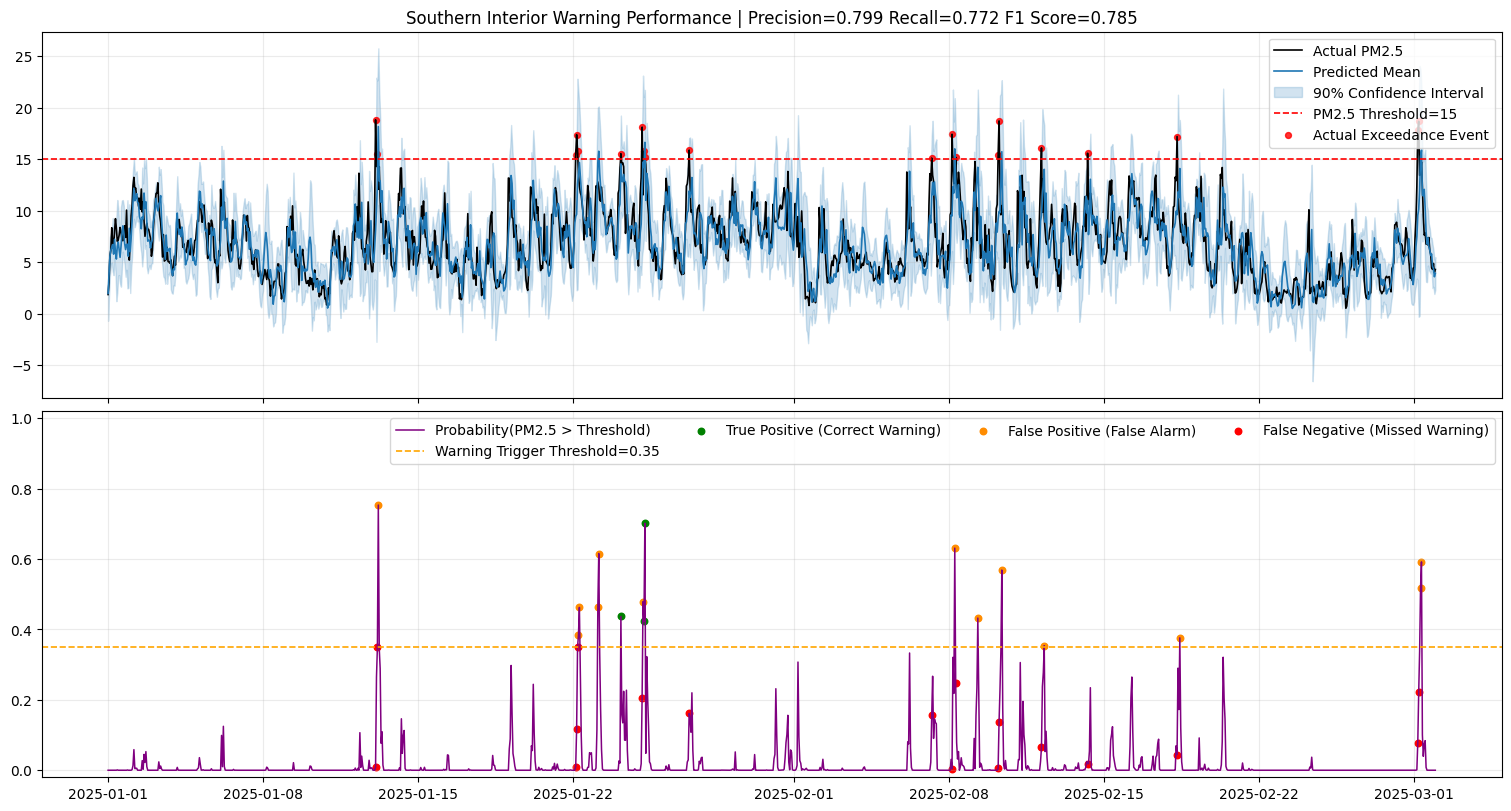

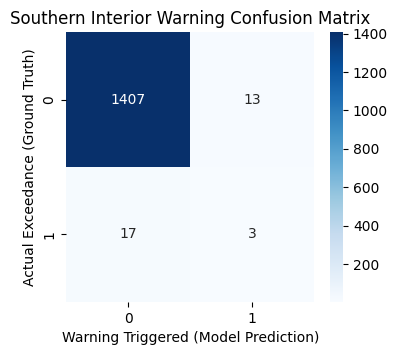

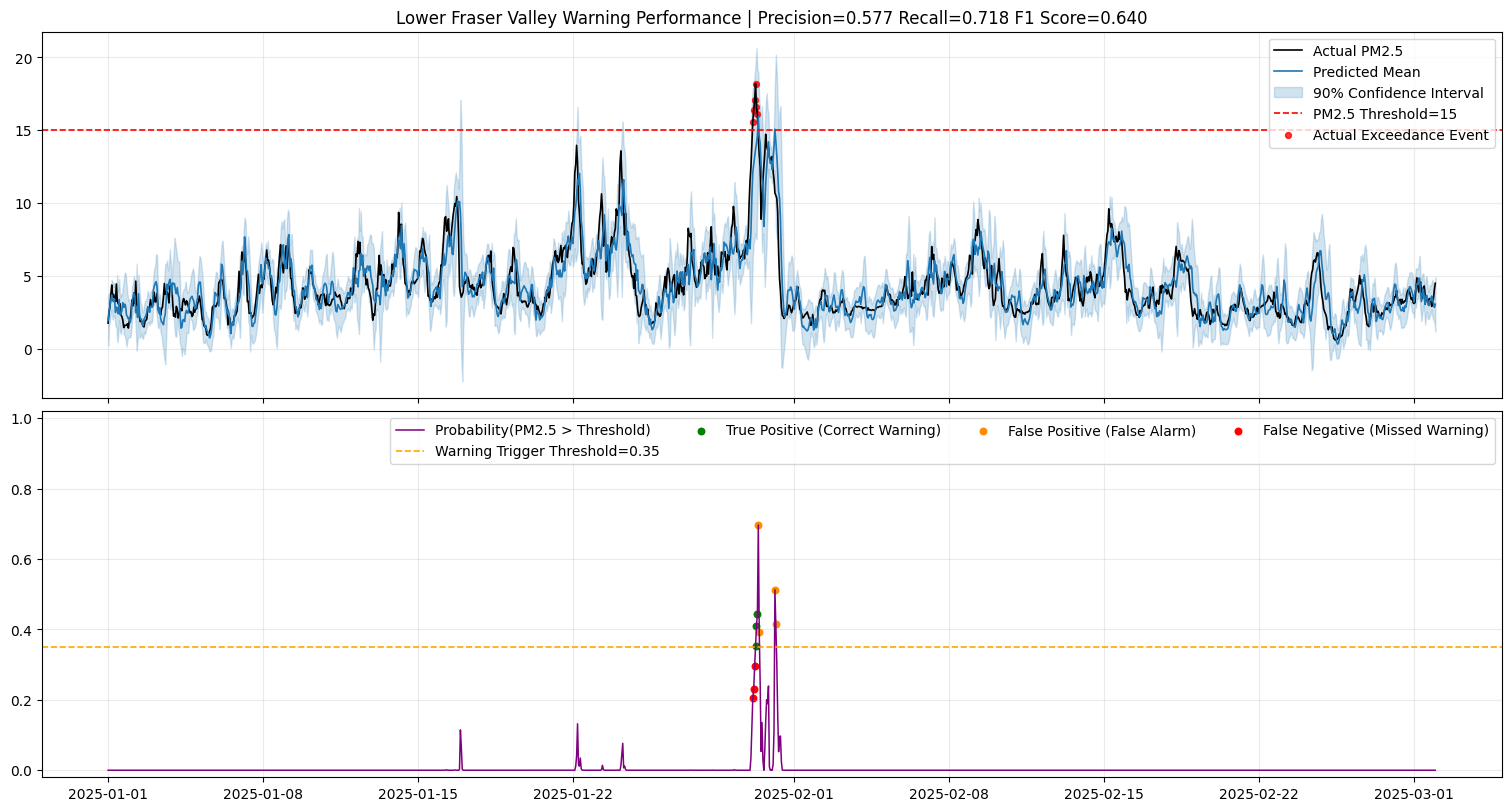

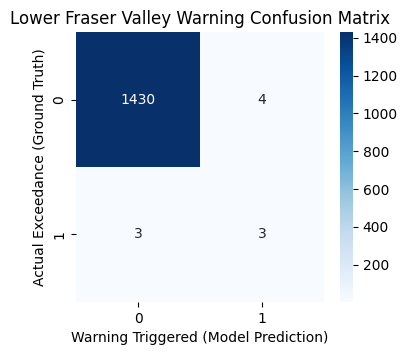


Pipeline execution complete. Warning outputs and plots saved to: c:\Users\User\Desktop\Github\Personal Website\Data-Science-Case-Study-1\Assets\Outputs\Model\image


In [6]:
# =========================
# Main Execution Pipeline
# =========================
if __name__ == "__main__":
    # 1. 讀取與處理原始資料
    dataset_file_path = PROJECT_DIRECTORY / "Dataset" / "Outputs" / "CS2_model_input.csv"
    raw_input_dataframe = pd.read_csv(dataset_file_path)
    raw_input_dataframe['Datetime_UTC'] = pd.to_datetime(raw_input_dataframe['Datetime_UTC'])
    
    # 將長格式 (Long format) 轉置為寬格式 (Wide format)，以區域作為欄位
    pivoted_dataframe = raw_input_dataframe.pivot(index='Datetime_UTC', columns='Zone', values='PM25').sort_index()
    # 移除時區資訊，避免在篩選年份 (index.year) 時出現錯誤
    pivoted_dataframe.index = pivoted_dataframe.index.tz_localize(None)

    print("Data Date Range:", pivoted_dataframe.index.min(), "-", pivoted_dataframe.index.max())
    print("Available Regions:", pivoted_dataframe.columns.tolist(), "\n")

    # 2. 訓練基礎 GAM 模型
    # 該步驟只負責將各區域的特徵擬合至預測平均值
    trained_gam_models_dictionary = train_regional_gam_models(
        input_dataframe=pivoted_dataframe, 
        training_end_year=2023
    )

    # 3. 執行推論管線產出 Classification Warnings
    # 結合 GAM (平均值預測) 與 GARCH (變異數推論)，計算超標機率並發布警報
    classification_report_dataframe, detailed_inference_dictionary, dynamic_threshold_records = generate_classification_warning_pipeline(
        input_dataframe=pivoted_dataframe,
        trained_gam_models_dictionary=trained_gam_models_dictionary,              
        pm25_physical_threshold=15,             # 真實環境中 PM2.5 認定為超標的數值
        risk_probability_threshold=0.35,        # 系統決定發布警報的機率門檻 (目前固定為 0.35)
        garch_calibration_year=2024,
        testing_year=2025,
        threshold_selection_mode="fixed"        # 若未來需要動態找閾值，可修改為 "target_recall_max3"
    )

    print("\n=== Classification Warning Report ===")
    display(classification_report_dataframe)

    # 4. 繪製並儲存警報診斷圖表
    for region_name in classification_report_dataframe.index:
        plot_classification_warning_diagnostics(
            region_name=region_name, 
            detailed_inference_dictionary=detailed_inference_dictionary, 
            summary_report_dataframe=classification_report_dataframe, 
            pm25_physical_threshold=15, 
            risk_probability_threshold=0.35, 
            plot_days_limit=60
        )
        
    print(f"\nPipeline execution complete. Warning outputs and plots saved to: {PLOT_OUTPUT_DIRECTORY}")